# Step 2 - Starting atmosphere (FAL-C clone + velocity)

Loads and checks the warm-start atmosphere from `make_start_atmosphere.py`: a lightweaver FAL-C
column resampled to `z' in [-100,1000] km` (20 km steps, relabeled so the model bottom is at -100 km
and tau=1 near z'~0; no extrapolation), cloned into a 128x128 map, with added **velocity structure**
(vz = a granulation-like horizontal pattern x a photospheric envelope, +-3 km/s). Saved SI to
`/dat/milic/adora_pinn_develop/`.

In [1]:
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt
d = np.load('/dat/milic/adora_pinn_develop/test_atm_falc_128.npz', allow_pickle=True)
z = d['z_km']
print('cube shape', d['T'].shape, ' z:', z[0], '..', z[-1], 'km  step', z[1]-z[0], 'km')
print('note :', str(d['note']))
for k in ['T','P','vz','Bx','By','Bz','vturb']:
    a = d[k]; print(f'  {k:5s} {a.min():+.3e} .. {a.max():+.3e}')

cube shape (128, 128, 56)  z: -100.0 .. 1000.0 km  step 20.0 km
note : z_km is relabeled z'=z_lw-100 (bottom->-100km, tau=1 near z'~0), no extrapolation; vz = V_AMP*cos(2pi 3x)cos(2pi 2y)*exp(-(z'/400km)^2), other channels cloned, B=0
  T     +4.502e+03 .. +9.400e+03
  P     +3.750e+00 .. +1.935e+04
  vz    -2.999e+03 .. +3.000e+03
  Bx    +0.000e+00 .. +0.000e+00
  By    +0.000e+00 .. +0.000e+00
  Bz    +0.000e+00 .. +0.000e+00
  vturb +5.294e+02 .. +2.507e+03


### Vertical profiles (column at pixel 0,0)
Standard FAL-C shape (T minimum ~z'540 km, monotonic P); vz at this pixel peaks near the photosphere.

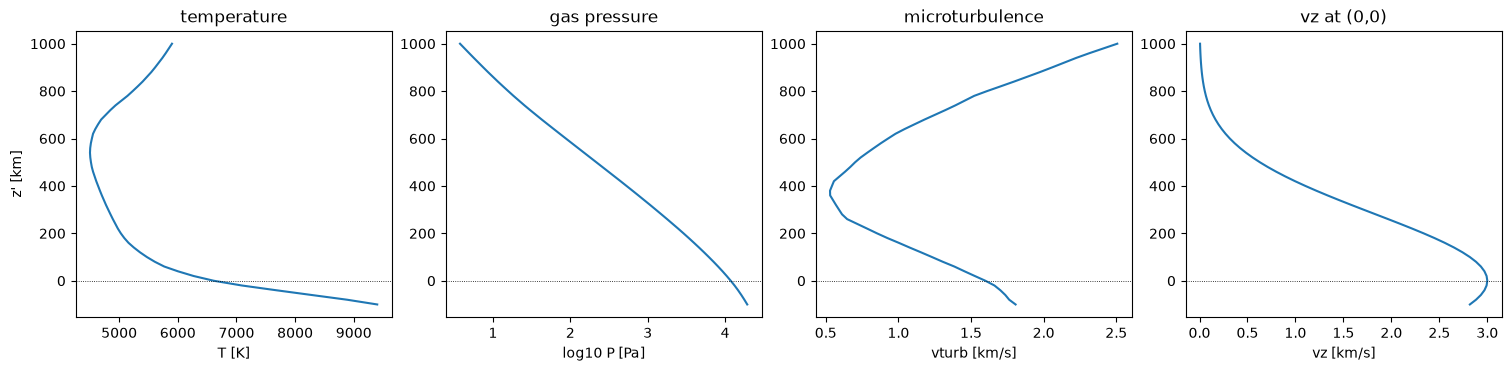

In [2]:
T = d['T'][0,0]; P = d['P'][0,0]; vt = d['vturb'][0,0]; vzc = d['vz'][0,0]
fig, ax = plt.subplots(1, 4, figsize=(15, 3.6), layout='constrained')
ax[0].plot(T, z); ax[0].set(xlabel='T [K]', ylabel="z' [km]", title='temperature')
ax[1].plot(np.log10(P), z); ax[1].set(xlabel='log10 P [Pa]', title='gas pressure')
ax[2].plot(vt/1e3, z); ax[2].set(xlabel='vturb [km/s]', title='microturbulence')
ax[3].plot(vzc/1e3, z); ax[3].set(xlabel='vz [km/s]', title='vz at (0,0)')
for a in ax: a.axhline(0, color='k', lw=0.6, ls=':')
plt.show()

### Horizontal structure
T, P, vturb, B are cloned (std across x,y = 0); only **vz** varies horizontally - the granulation-like
pattern, strongest near the photosphere.

max std across (x,y) per channel (0 -> cloned):
  T     3.314e-09
  P     5.664e-09
  vz    1.512e+03
  Bx    0.000e+00
  By    0.000e+00
  Bz    0.000e+00
  vturb 6.639e-10


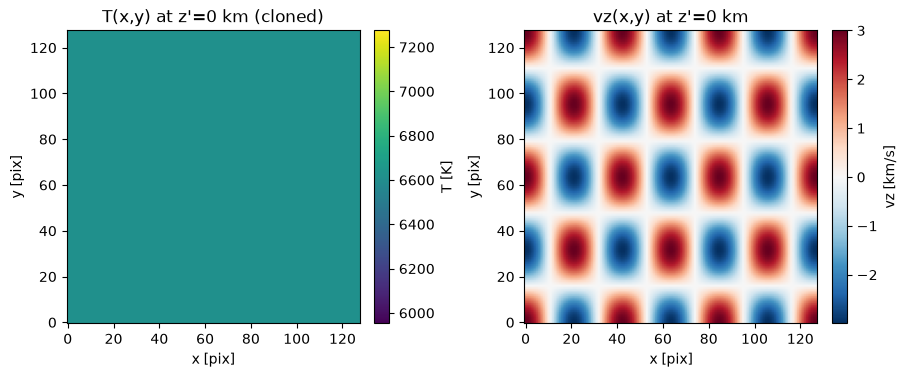

In [3]:
stds = {k: float(d[k].std(axis=(0,1)).max()) for k in ['T','P','vz','Bx','By','Bz','vturb']}
print('max std across (x,y) per channel (0 -> cloned):')
for k,v in stds.items(): print(f'  {k:5s} {v:.3e}')
iz = int(np.argmin(np.abs(z - 0.0)))   # photosphere slice z'~0
fig, ax = plt.subplots(1, 2, figsize=(9, 3.6), layout='constrained')
im0 = ax[0].imshow(d['T'][:,:,iz].T, origin='lower'); plt.colorbar(im0, ax=ax[0], label='T [K]')
ax[0].set(title=f"T(x,y) at z'={z[iz]:.0f} km (cloned)", xlabel='x [pix]', ylabel='y [pix]')
im1 = ax[1].imshow(d['vz'][:,:,iz].T/1e3, origin='lower', cmap='RdBu_r')
plt.colorbar(im1, ax=ax[1], label='vz [km/s]')
ax[1].set(title=f"vz(x,y) at z'={z[iz]:.0f} km", xlabel='x [pix]', ylabel='y [pix]')
plt.show()